In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\Dhyaneshwari\Downloads\salesdaily.csv")
print(df.shape)
df.head(5)

(2106, 13)


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   str    
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   str    
dtypes: float64(8), int64(3), str(2)
memory usage: 214.0 KB


In [5]:
df.isnull().sum()

datum           0
M01AB           0
M01AE           0
N02BA           0
N02BE           0
N05B            0
N05C            0
R03             0
R06             0
Year            0
Month           0
Hour            0
Weekday Name    0
dtype: int64

In [7]:
df.dtypes

datum               str
M01AB           float64
M01AE           float64
N02BA           float64
N02BE           float64
N05B            float64
N05C            float64
R03             float64
R06             float64
Year              int64
Month             int64
Hour              int64
Weekday Name        str
dtype: object

In [8]:
df.describe()

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour
count,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000
mean,5.033683,3.895830,3.880441,29.917095,8.853627,0.593522,5.512262,2.900198,2016.401235,6.344255,275.945869
std,2.737579,2.133337,2.384010,15.590966,5.605605,1.092988,6.428736,2.415816,1.665060,3.386954,1.970547
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2014.000000,1.000000,190.000000
25%,3.000000,2.340000,2.000000,19.000000,5.000000,0.000000,1.000000,1.000000,2015.000000,3.000000,276.000000
50%,4.990000,3.670000,3.500000,26.900000,8.000000,0.000000,4.000000,2.000000,2016.000000,6.000000,276.000000
75%,6.670000,5.138000,5.200000,38.300000,12.000000,1.000000,8.000000,4.000000,2018.000000,9.000000,276.000000
max,17.340000,14.463000,16.000000,161.000000,54.833333,9.000000,45.000000,15.000000,2019.000000,12.000000,276.000000


In [9]:
df.duplicated().sum()

np.int64(0)

In [11]:
drug_cols = ['M01AB','M01AE','N02BA','N02BE','N05B','N05C',	'R03','R06']
total_sales = df[drug_cols].sum()
print(total_sales)

M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
N02BE    63005.402708
N05B     18645.737500
N05C      1249.958333
R03      11608.822917
R06       6107.817500
dtype: float64


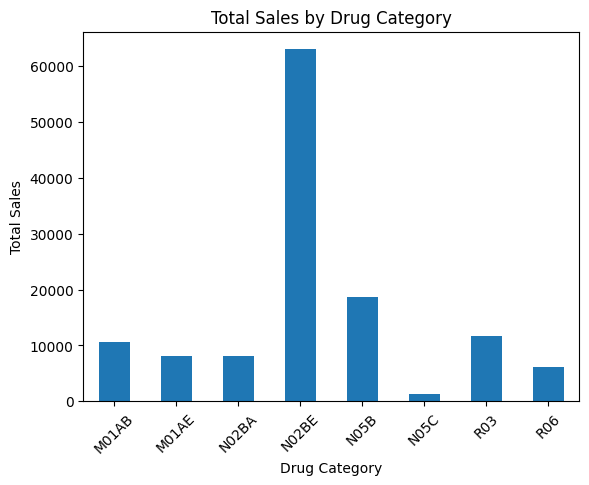

In [12]:
total_sales.plot(kind='bar')

plt.title("Total Sales by Drug Category")
plt.xlabel("Drug Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [14]:
total_sales = df[drug_cols].sum()
total_sales = total_sales.sort_values(ascending=False)
print(total_sales.head(3))

N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
dtype: float64


In [15]:
df['datum'] = pd.to_datetime(df['datum'])

In [16]:
jan_2025 = df[
    (df['datum'].dt.year == 2015) &
    (df['datum'].dt.month == 1)
]

sales = jan_2025[drug_cols].sum()
print(sales.sort_values(ascending=False).head(3))

N02BE    1044.24
N05B      463.00
R03       177.25
dtype: float64


In [17]:
jul_2016 = df[
    (df['datum'].dt.year == 2016) &
    (df['datum'].dt.month == 7)
]

sales = jul_2016[drug_cols].sum()

print(sales.sort_values(ascending=False).head(3))

N02BE    652.362000
N05B     240.000000
M01AB    194.528333
dtype: float64


In [18]:
sep_2017 = df[
    (df['datum'].dt.year == 2017) &
    (df['datum'].dt.month == 9)
]

sales = sep_2017[drug_cols].sum()

print(sales.sort_values(ascending=False).head(3))

N02BE    863.75
N05B     223.00
R03      139.00
dtype: float64


In [19]:
df_2017 = df[df['datum'].dt.year == 2017]

frequency = (df_2017[drug_cols] > 0).sum()

print(frequency.sort_values(ascending=False))

N02BE    361
M01AB    360
M01AE    360
N05B     356
N02BA    350
R06      329
R03      286
N05C      99
dtype: int64


In [20]:
average_sales = df[drug_cols].mean()
print(average_sales.sort_values(ascending=False))

N02BE    29.917095
N05B      8.853627
R03       5.512262
M01AB     5.033683
M01AE     3.895830
N02BA     3.880441
R06       2.900198
N05C      0.593522
dtype: float64


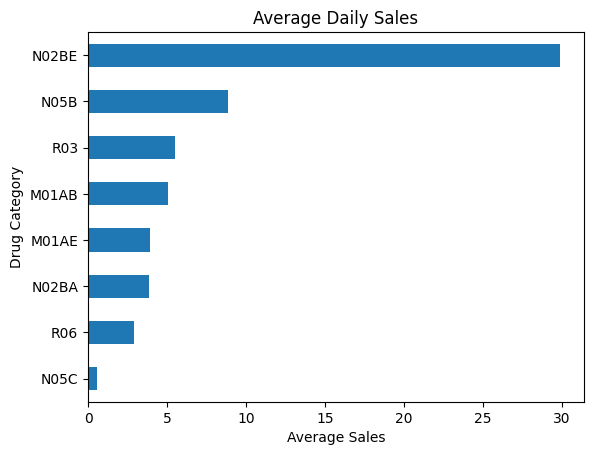

In [21]:
average_sales.sort_values().plot(kind='barh')

plt.title("Average Daily Sales")
plt.xlabel("Average Sales")
plt.ylabel("Drug Category")
plt.show()

In [22]:
monthly_r03 = df.groupby('Month')['R03'].mean()

print(monthly_r03)

Month
1     6.835980
2     6.896943
3     6.290323
4     5.771528
5     5.006944
6     4.350000
7     2.956989
8     3.102151
9     4.402315
10    7.208589
11    6.226667
12    7.916129
Name: R03, dtype: float64


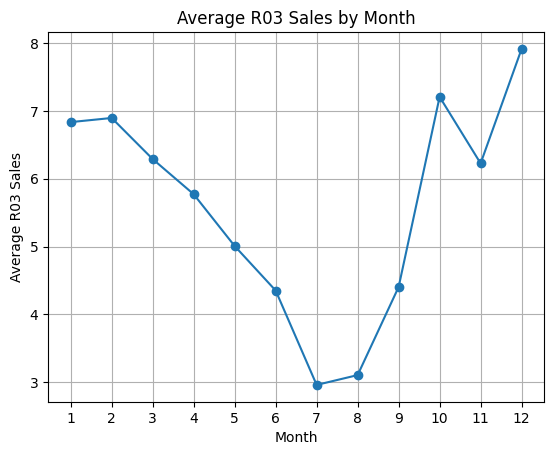

In [23]:
monthly_r03.plot(kind='line', marker='o')

plt.title("Average R03 Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average R03 Sales")
plt.xticks(range(1, 13))
plt.grid()
plt.show()